In [81]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [82]:
df = pd.read_csv("/Users/evansmith/Desktop/ds-studio-ii/archive/NFL Play by Play 2009-2018 (v5).csv")

/var/folders/87/k687kh2n1r377mqzh_gtkssr0000gn/T/ipykernel_42572/1535347164.py:1: DtypeWarning: Columns (42,166,167,168,169,174,175,178,179,182,183,188,189,190,191,194,195,203,204,205,218,219,220,231,232,233,238,240,241,249) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/evansmith/Desktop/ds-studio-ii/archive/NFL Play by Play 2009-2018 (v5).csv")


In [83]:
# Finds number of rows and columns
df.shape

(449371, 255)

In [84]:
# Total number of field goals attempted

print(df["field_goal_result"].value_counts())
field_goal_total = df["field_goal_result"].value_counts().sum()
print("The total number of field goals is:", field_goal_total)

field_goal_result
made       8226
missed     1381
blocked     206
Name: count, dtype: int64
The total number of field goals is: 9813


In [85]:
# Total number of iced kicks

iced_kick_total = 0
for i in range(len(df) - 1):
    if (df.loc[i, "timeout"] > 0 and
        (df.loc[i + 1, "field_goal_result"] == "made" or df.loc[i + 1, "field_goal_result"] == "missed" or df.loc[i + 1, "field_goal_result"] == "blocked") and
        (df.loc[i, "timeout_team"] == df.loc[i, "defteam"])):
        iced_kick_total += 1

print(iced_kick_total)

565


In [86]:
# Total number of non iced kicks

non_iced_kick_total = 0
for i in range(len(df) - 1):
    if (df.loc[i, "timeout"] == 0 and
        (df.loc[i + 1, "field_goal_result"] == "made" or df.loc[i + 1, "field_goal_result"] == "missed" or df.loc[i + 1, "field_goal_result"] == "blocked")):
        non_iced_kick_total += 1

print(non_iced_kick_total)

8413


In [87]:
penalty = 0
for i in range(len(df) - 1):
    if (df.loc[i, "play_type"] == "no_play" and
        (df.loc[i, "timeout"] == 0) and
        (df.loc[i + 1, "field_goal_result"] == "made" or df.loc[i + 1, "field_goal_result"] == "missed" or df.loc[i + 1, "field_goal_result"] == "blocked")):
        penalty += 1
print(penalty)

295


In [88]:
offensive_timeout_before_fg = 0
for i in range(len(df) - 1):
    if (df.loc[i, "timeout"] > 0 and
        df.loc[i, "timeout_team"] == df.loc[i, "posteam"] and
        (df.loc[i + 1, "field_goal_result"] in ["made", "missed", "blocked"])):
        offensive_timeout_before_fg += 1

print(offensive_timeout_before_fg)

616


In [89]:
# Defensive timeout before FG (iced)
iced_kick_total = 0

# Offensive timeout before FG
offensive_timeout_total = 0

# Penalty before FG (no_play but no timeout)
penalty_total = 0

# No stoppage before FG
non_iced = 0

for i in range(len(df) - 1):
    if df.loc[i + 1, "field_goal_result"] in ["made", "missed", "blocked"]:
        if df.loc[i, "timeout"] > 0 and df.loc[i, "timeout_team"] == df.loc[i, "defteam"]:
            iced_kick_total += 1
        elif df.loc[i, "timeout"] > 0 and df.loc[i, "timeout_team"] == df.loc[i, "posteam"]:
            offensive_timeout_total += 1
        elif df.loc[i, "play_type"] == "no_play" and df.loc[i, "timeout"] == 0:
            penalty_total += 1
        else:
            non_iced += 1

print("Iced:", iced_kick_total)
print("Offensive timeout:", offensive_timeout_total)
print("Penalty:", penalty_total)
print("Non-Iced:", non_iced)
print("Sum:", iced_kick_total + offensive_timeout_total + penalty_total + non_iced)
print("Total FGs:", field_goal_total)

Iced: 565
Offensive timeout: 616
Penalty: 295
Non-Iced: 8337
Sum: 9813
Total FGs: 9813


In [90]:
# Total number of iced kicks that were made

iced_kick_make = 0
for i in range(len(df) - 1):
    if (df.loc[i, "timeout"] > 0 and
        (df.loc[i, "timeout_team"] == df.loc[i, "defteam"]) and
        (df.loc[i + 1, "field_goal_result"] == "made")):
        iced_kick_make += 1

print(iced_kick_make)

441


In [91]:
# Total number of iced kicks that were missed

iced_kick_miss = 0
for i in range(len(df) - 1):
    if (df.loc[i, "timeout"] > 0 and
        (df.loc[i, "timeout_team"] == df.loc[i, "defteam"]) and
        (df.loc[i + 1, "field_goal_result"] == "missed" or df.loc[i + 1, "field_goal_result"] == "blocked")):
        iced_kick_miss += 1

print(iced_kick_miss)

124


In [92]:
# Total number of non iced kicks made

non_iced_kick_make = 0
for i in range(len(df) - 1):
    if (df.loc[i + 1, "field_goal_result"] == "made" and
            (df.loc[i, "timeout"] == 0 or df.loc[i, "timeout_team"] != df.loc[i, "defteam"]) and
            (df.loc[i, "timeout"] == 0 or df.loc[i, "timeout_team"] != df.loc[i, "posteam"]) and
            (df.loc[i, "play_type"] != "no_play" or df.loc[i, "timeout"] != 0)):
        non_iced_kick_make += 1

print(non_iced_kick_make)


7056


In [93]:
# Total number of non iced kicks missed

non_iced_kick_miss = 0
for i in range(len(df) - 1):
    if ((df.loc[i + 1, "field_goal_result"] == "missed" or df.loc[i + 1, "field_goal_result"] == "blocked") and
            (df.loc[i, "timeout"] == 0 or df.loc[i, "timeout_team"] != df.loc[i, "defteam"]) and
            (df.loc[i, "timeout"] == 0 or df.loc[i, "timeout_team"] != df.loc[i, "posteam"]) and
            (df.loc[i, "play_type"] != "no_play" or df.loc[i, "timeout"] != 0)):
        non_iced_kick_miss += 1

print(non_iced_kick_miss)

1281


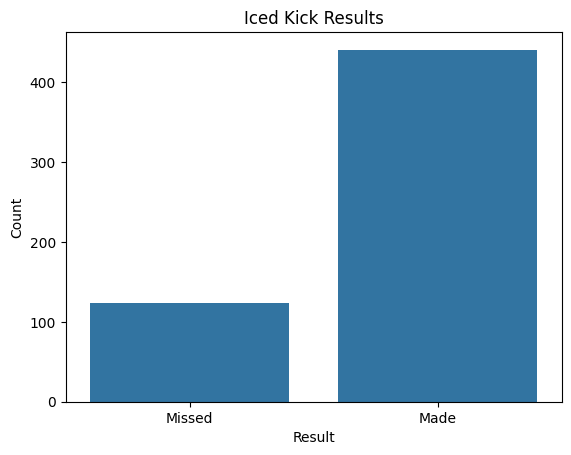

In [94]:
# Barplot of iced kicks

iced_df = pd.DataFrame({
    "Result": ["Missed", "Made"],
    "Count": [iced_kick_miss, iced_kick_make]
})

sns.barplot(x="Result", y="Count", data=iced_df)
plt.title("Iced Kick Results")
plt.show()

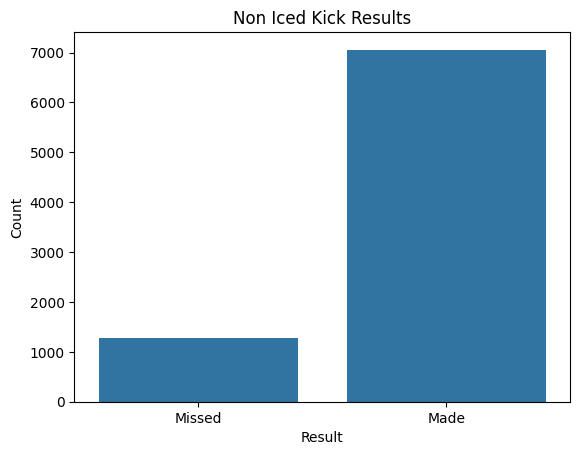

In [95]:
# Barplot of non iced kicks

non_iced_df = pd.DataFrame({
    "Result": ["Missed", "Made"],
    "Count": [non_iced_kick_miss, non_iced_kick_make]
})

sns.barplot(x="Result", y="Count", data=non_iced_df)
plt.title("Non Iced Kick Results")
plt.show()

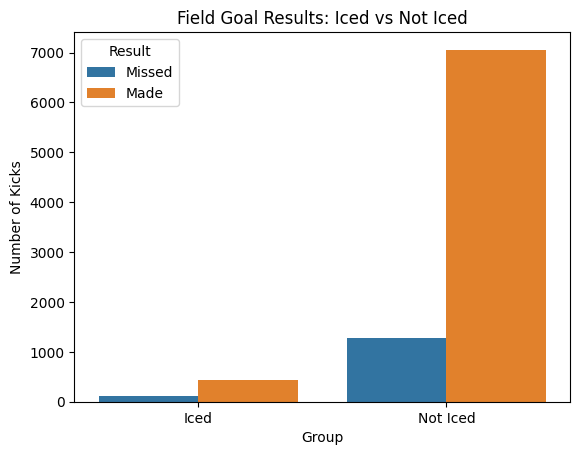

In [96]:
# Barplot of Iced and Not Iced combined 

data = pd.DataFrame({
    "Group": ["Iced", "Iced", "Not Iced", "Not Iced"],
    "Result": ["Missed", "Made", "Missed", "Made"],
    "Count": [iced_kick_miss, iced_kick_make, non_iced_kick_miss, non_iced_kick_make]
})

sns.barplot(data=data, x="Group", y="Count", hue="Result")

plt.title("Field Goal Results: Iced vs Not Iced")
plt.ylabel("Number of Kicks")
plt.show()

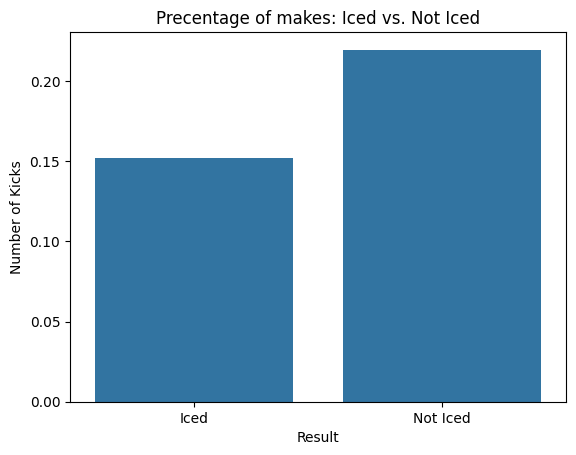

In [97]:
# Barplot of precentage of iced vs not iced kicks missed

data = pd.DataFrame({
    "Result": ["Iced", "Not Iced"],
    "Count": [(non_iced_kick_miss / non_iced_kick_total), (iced_kick_miss / iced_kick_total)]
})

sns.barplot(data=data, x="Result", y="Count")

plt.title("Precentage of makes: Iced vs. Not Iced")
plt.ylabel("Number of Kicks")
plt.show()

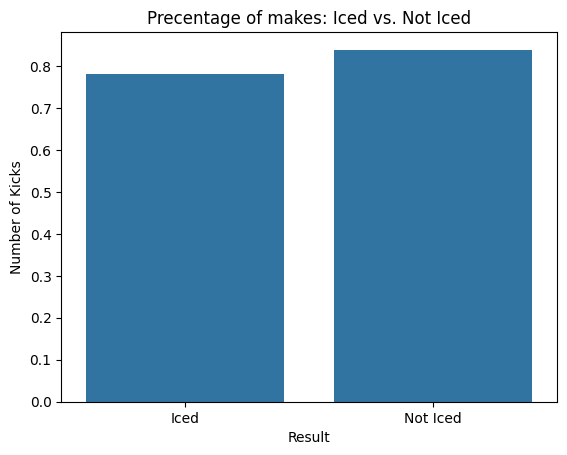

In [98]:
# Barplot of precentage of iced vs not iced kicks made

data = pd.DataFrame({
    "Result": ["Iced", "Not Iced"],
    "Count": [(iced_kick_make / iced_kick_total), (non_iced_kick_make / non_iced_kick_total)]
})

sns.barplot(data=data, x="Result", y="Count")

plt.title("Precentage of makes: Iced vs. Not Iced")
plt.ylabel("Number of Kicks")
plt.show()

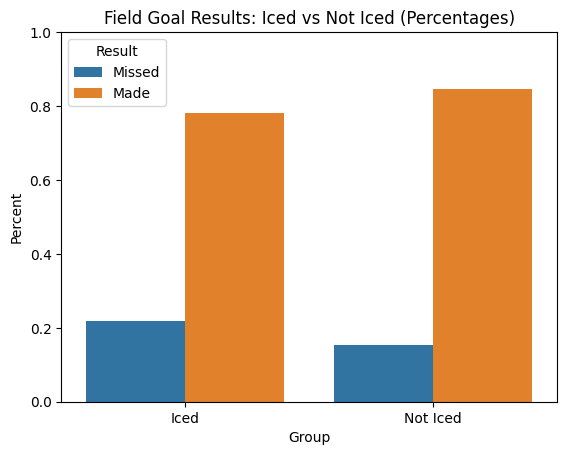

In [105]:
# Barplot of precentage of iced vs not iced combined

iced_total = iced_kick_make + iced_kick_miss
non_iced_total = non_iced_kick_make + non_iced_kick_miss

data_percent = pd.DataFrame({
    "Group": ["Iced", "Iced", "Not Iced", "Not Iced"],
    "Result": ["Made", "Missed", "Made", "Missed"],
    "Percent": [
        iced_kick_make / iced_total,
        iced_kick_miss / iced_total,
        non_iced_kick_make / non_iced_total,
        non_iced_kick_miss / non_iced_total
    ]
})

sns.barplot(
    data=data_percent,
    x="Group",
    y="Percent",
    hue="Result",
    hue_order=["Missed", "Made"]
)

plt.ylim(0,1)
plt.title("Field Goal Results: Iced vs Not Iced (Percentages)")
plt.show()

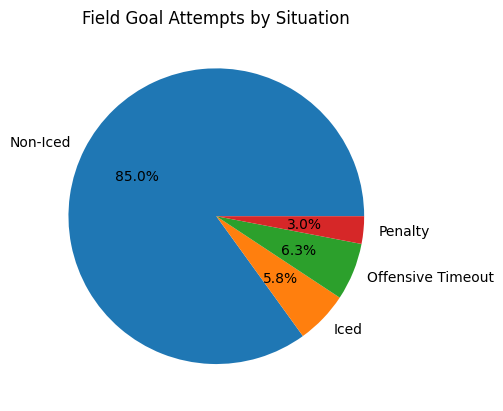

In [102]:
labels = ['Non-Iced', 'Iced', 'Offensive Timeout', 'Penalty']
sizes = [non_iced, iced_kick_total, offensive_timeout_total, penalty_total]

plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title('Field Goal Attempts by Situation')
plt.show()

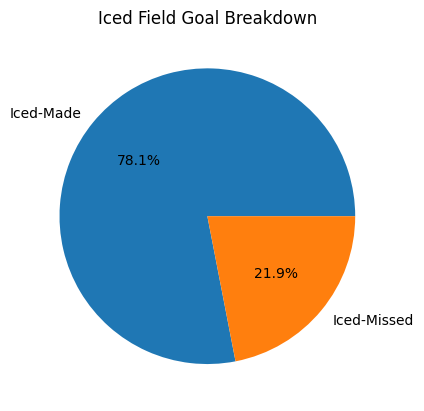

In [103]:
labels = ["Iced-Made", "Iced-Missed"]
sizes = [iced_kick_make, iced_kick_miss]

plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title("Iced Field Goal Breakdown")
plt.show()

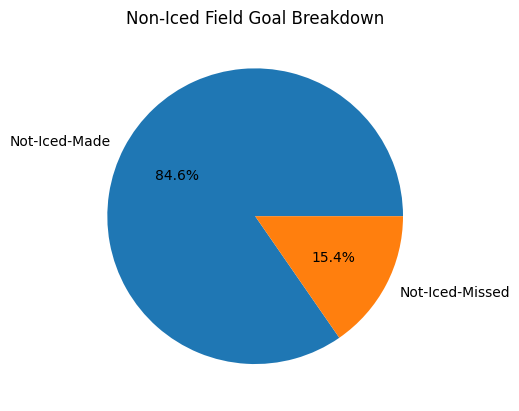

In [104]:
labels = ["Not-Iced-Made", "Not-Iced-Missed"]
sizes = [non_iced_kick_make, non_iced_kick_miss]

plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title("Non-Iced Field Goal Breakdown")
plt.show()

In [100]:
from statsmodels.stats.proportion import proportions_ztest

In [101]:
# Since the p-value is less than .05 I can conclude that icing the kicker is statistically significant and works in the NFL from 2009-2018.

stat, pval = proportions_ztest([iced_kick_miss, non_iced_kick_miss], [(iced_kick_make + iced_kick_miss), (non_iced_kick_make + non_iced_kick_miss)])
print('{0:0.10f}'.format(pval))

0.0000328629
